/var/folders/05/_vxzr9653lg058wd1tp1rdyr0000gn/T/ipykernel_54670/1776487480.py:28: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           1       0.62      0.65      0.63     21901
           2       0.44      0.17      0.24     16992
           3       0.13      0.27      0.18      4282
           4       0.26      0.47      0.34      6223

    accuracy                           0.43     49398
   macro avg       0.36      0.39      0.35     49398
weighted avg       0.47      0.43      0.42     49398



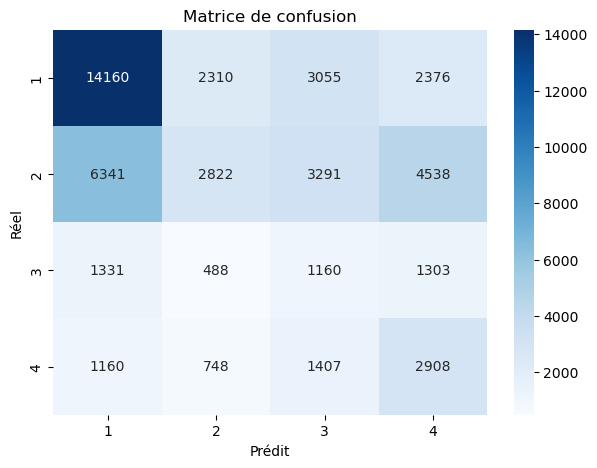

In [7]:
##############
# Linear Regression with One-Hot Encoding
##############

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_val_predict, cross_validate
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Importation des données

path = os.path.join( "..", "data", "processed", "score_cat_preprocessed.csv")
df = pd.read_csv(path)
df.drop(columns=["com","score",'nb_accidents',"grav"], inplace=True)

# --- 1. Split
X = df.drop(columns="score_cat")
y = df["score_cat"]

# Tous les champs sont catégoriels → on les convertit en string
X = X.astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)



cols_to_exclude = ['dep'] 
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

# Préprocesseur combiné
preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cols_to_ohe),
    ('target_enc', TargetEncoder(smoothing=10, min_samples_leaf=1), ['dep'])
], remainder='passthrough')


# --- 2. Pipeline : OHE (sparse) + régression linéaire
pipe = ImbPipeline([
    ('encoding', preprocessor),
    ('undersampling', RandomUnderSampler(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, multi_class='multinomial'))
])

# --- 3. Entraînement
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)


# --- 4. Évaluation
print(classification_report(y_test, y_pred))


# --- Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())  
# --- Affichage
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

/var/folders/05/_vxzr9653lg058wd1tp1rdyr0000gn/T/ipykernel_56081/2910185649.py:25: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


              precision    recall  f1-score   support

           1       0.62      0.56      0.59     21901
           2       0.40      0.22      0.28     16992
           3       0.12      0.25      0.16      4282
           4       0.26      0.47      0.34      6223

    accuracy                           0.41     49398
   macro avg       0.35      0.38      0.34     49398
weighted avg       0.45      0.41      0.41     49398



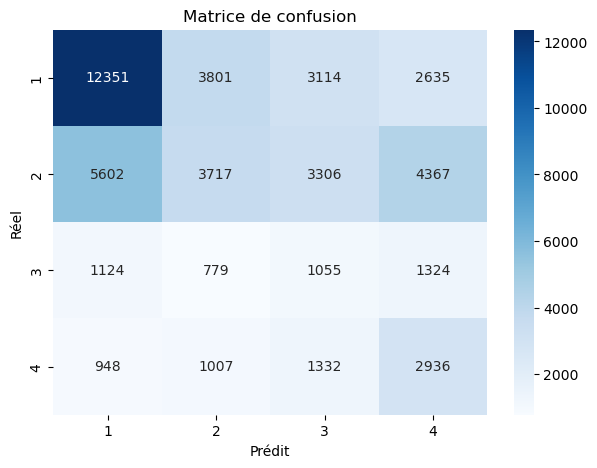

In [3]:
##############
# Random Forest 
##############
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import OneHotEncoder
from imblearn.under_sampling import RandomUnderSampler

# Importation des données

path = os.path.join( "..", "data", "processed", "score_cat_preprocessed.csv")
df = pd.read_csv(path)
df.drop(columns=["com","score",'nb_accidents',"grav"], inplace=True)

# --- 1. Split
X = df.drop(columns="score_cat")
y = df["score_cat"]


# Tous les champs sont catégoriels → on les convertit en string
X = X.astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)



cols_to_exclude = ['dep'] 
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

# Préprocesseur combiné
preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cols_to_ohe),
    ('target_enc', TargetEncoder(smoothing=10, min_samples_leaf=1), ['dep'])
], remainder='passthrough')


# --- 2. Pipeline : OHE (sparse) + régression linéaire
pipe = ImbPipeline([
    ('encoding', preprocessor),
    ('undersampling', RandomUnderSampler(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# --- 3. Entraînement
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)


# --- 4. Évaluation
print(classification_report(y_test, y_pred))


# --- Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())  
# --- Affichage
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

In [1]:
##############
# XG Boost with under-sampling
##############


import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer


# === 1. Chargement des données
# Importation des données

path = os.path.join( "..", "data", "processed", "score_cat_preprocessed.csv")
df = pd.read_csv(path)
df.drop(columns=["com","score",'nb_accidents',"grav"], inplace=True)

# --- 1. Split
X = df.drop(columns="score_cat")
y = df["score_cat"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)  # y = [1, 2, 3, 4] ➜ y_encoded = [0, 1, 2, 3]


X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)




# === 4. TargetEncoding sur 'com'
te = TargetEncoder()
X_train['dep_encoded'] = te.fit_transform(X_train['dep'], y_train)
X_test['dep_encoded'] = te.transform(X_test['dep'])
X_train.drop(columns='dep', inplace=True)
X_test.drop(columns='dep', inplace=True)

# === 5. Colonnes à OHE

cols_to_exclude = ['dep_encoded']
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]


# === 6. Pipeline de préprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe)
    ],
    remainder='passthrough',
    verbose_feature_names_out=True
)


# === 7. Pipeline complète avec XGBoost et undersampling
# === 6. Pipeline complète avec conversion en array

def convert_to_array(X):
    return np.asarray(X, dtype=np.float32)

pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('to_array', FunctionTransformer(convert_to_array, validate=False)),
    ('undersampling', RandomUnderSampler(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=200,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    ))
])

# === 8. Entraînement
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_pred_original = le.inverse_transform(y_pred)  # retourne [1, 2, 3, 4]


# === 9. Évaluation
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

/var/folders/05/_vxzr9653lg058wd1tp1rdyr0000gn/T/ipykernel_56492/3991016259.py:29: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


: 